# Responsible Credit Scoring
## Predictive Risk Modeling & Ethical Fairness Auditing
### Student: Carlos Elizondo
### Student Number: 500890062
### Supervisor: Tamer Abdou
**Toronto Metropolitan University**

## 1. Setup & Load

Import the libraries needed for data handling, visualization, and modeling, then mounting Google
Drive and loading the master feature matrix produced by the feature selection and relational
aggregation notebook.

In [ ]:
# Core libraries
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report
)
from scipy.stats import pointbiserialr, chi2_contingency

RANDOM_STATE = 42

In [ ]:
# Mount Drive and load the master feature matrix
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/CIND820_Project/master_feature_matrix.csv')
print(f"Loaded master matrix: {df.shape[0]:,} rows, {df.shape[1]} columns")

Mounted at /content/drive
Loaded master matrix: 307,511 rows, 66 columns


## 2. Data Quality Checks

Before touching the data, i want to confirm it's structurally sound: no duplicate records, no duplicate
applicant IDs, and identify exactly which columns have missing values and how much.

In [ ]:
#Checking master feature matrix to see what types are in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 66 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SK_ID_CURR                  307511 non-null  int64  
 1   TARGET                      307511 non-null  int64  
 2   CODE_GENDER                 307511 non-null  object 
 3   DAYS_BIRTH                  307511 non-null  int64  
 4   AMT_INCOME_TOTAL            307511 non-null  float64
 5   AMT_CREDIT                  307511 non-null  float64
 6   AMT_ANNUITY                 307499 non-null  float64
 7   AMT_GOODS_PRICE             307233 non-null  float64
 8   NAME_CONTRACT_TYPE          307511 non-null  object 
 9   DAYS_EMPLOYED               252137 non-null  float64
 10  DAYS_REGISTRATION           307511 non-null  float64
 11  DAYS_ID_PUBLISH             307511 non-null  int64  
 12  OCCUPATION_TYPE             211120 non-null  object 
 13  ORGANIZATION_T

In [ ]:
#printing out first 5 rows to see some of the variables inside the master feature matrix
df.head()

,SK_ID_CURR,TARGET,CODE_GENDER,DAYS_BIRTH,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_CONTRACT_TYPE,DAYS_EMPLOYED,...,POS_AVG_COMPLETION_RATIO,CC_AVG_UTILIZATION,CC_MAX_DPD,CC_AVG_PAYMENT_RATIO,CC_TOTAL_CARDS,RATIO_DEBT_TO_INCOME,RATIO_ANNUITY_TO_INCOME,RATIO_CREDIT_TO_GOODS,AGE_YEARS,EMPLOYED_YEARS
0,100002,1,M,-9461,202500.0,406597.5,24700.5,351000.0,Cash loans,-637.0,...,0.375000,NaN,NaN,NaN,NaN,2.007889,0.121978,1.158397,25.920548,1.745205
1,100003,0,F,-16765,270000.0,1293502.5,35698.5,1129500.0,Cash loans,-1188.0,...,0.455357,NaN,NaN,NaN,NaN,4.790750,0.132217,1.145199,45.931507,3.254795
2,100004,0,M,-19046,67500.0,135000.0,6750.0,135000.0,Revolving loans,-225.0,...,0.437500,NaN,NaN,NaN,NaN,2.000000,0.100000,1.000000,52.180822,0.616438
3,100006,0,F,-19005,135000.0,312682.5,29686.5,297000.0,Cash loans,-3039.0,...,0.429167,0.0,0.0,NaN,1.0,2.316167,0.219900,1.052803,52.068493,8.326027
4,100007,0,M,-19932,121500.0,513000.0,21865.5,513000.0,Cash loans,-3038.0,...,0.442439,NaN,NaN,NaN,NaN,4.222222,0.179963,1.000000,54.608219,8.323288


In [ ]:
# Duplicate check
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate SK_ID_CURR:", df['SK_ID_CURR'].duplicated().sum())

Exact duplicate rows: 0
Duplicate SK_ID_CURR: 0


## 2.1 Train/Test Split — Before Any Preprocessing

**This is moved here deliberately, ahead of missing-value handling, encoding, outlier removal, and feature selection.** In the previous version of this notebook, all of those steps were fit on the full 307,511-row dataset before the split happened — meaning the test set's values (and, in the case of Chi-Square, the test set's actual TARGET labels) quietly influenced every downstream decision before the model was ever evaluated on it. That makes the reported test performance optimistic in a way that would not reproduce on genuinely new applicants.

From this point forward, every learned statistic — imputation medians, the occupation-mode lookup, one-hot category vocabularies, Chi-Square scores, permutation importances — is computed from `X_train` only, then applied to `X_test` using the training-derived values. `X_test`/`y_test` are touched exactly once in this notebook: the single final evaluation of the optimized model in Section 11.

In [ ]:
# SK_ID_CURR is an identifier, never a feature — dropped here immediately so it can't
# accidentally show up in the correlation heatmap or Chi-Square scores in Section 6
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows, {X_train.shape[1]} columns")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"\nTraining class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 246,008 rows, 64 columns
Test set: 61,503 rows

Training class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Test class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


## 3. Handling Missing Values

No column is imputed the same way — the fill strategy depends on *why* the value is missing. Every statistic used to fill a value (a median, a mode) is computed from `X_train` only and then applied to both `X_train` and `X_test` — `X_test` never contributes to deciding what a fill value should be, it only receives one.

- **Occupation type:** applicants with no employment history are labeled "Not_Employed" (a fixed   rule, not a learned statistic); applicants who are employed but didn't have an occupation recorded   are filled with the most common occupation for their education level, where "most common" is   determined from the training set only.
- **Behavioral history columns** (credit card, bureau, previous application, installment, and   POS/cash aggregates): a missing value here means the applicant has no record in that source   table at all — not a random gap. These are filled with a fixed 0 and given a companion flag column,   so no training-derived statistic is involved.
- **External credit bureau scores (EXT_SOURCE_1/2/3):** filled with the training-set median, plus a   flag, since a missing score likely means the external source had no data on this applicant.
- **Employment length:** filled with a fixed 0 and flagged, since missing here means not currently   employed, not "zero experience."
- **Remaining small-missingness numeric columns** (each under 0.5% missing): filled with the   training-set median, no flag needed.
- Rows with an unspecified/unknown gender value are dropped from each split independently in Section 4.

### 3.1 How much is missing, and where

Before deciding how to fill anything, get a full picture of which columns have missing values and how severe each gap is. This is checked on `X_train` only — even exploratory data analysis stays within the training set from this point on, so no decision made later is shaped by having glimpsed the test set.

In [ ]:
# Missing value summary — computed on X_train only
missing = pd.DataFrame({
    'Missing Count': X_train.isnull().sum(),
    'Missing %': (X_train.isnull().sum() / len(X_train) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Columns with missing values: {len(missing)}")
print(missing)

Columns with missing values: 46
                            Missing Count  Missing %
CC_AVG_PAYMENT_RATIO               198511      80.69
CC_AVG_UTILIZATION                 177029      71.96
CC_TOTAL_CARDS                     176325      71.67
CC_MAX_DPD                         176325      71.67
BURBAL_MONTHS_OVERDUE              172342      70.06
BURBAL_TOTAL_MONTHS                172342      70.06
BURBAL_MONTHS_CLOSED               172342      70.06
EXT_SOURCE_1                       138595      56.34
BUR_MAX_OVERDUE_AMT                 99068      40.27
OCCUPATION_TYPE                     76940      31.28
EXT_SOURCE_3                        48805      19.84
DAYS_EMPLOYED                       44143      17.94
EMPLOYED_YEARS                      44143      17.94
BUR_AVG_UTILIZATION                 42140      17.13
BUR_TOTAL_DEBT                      41152      16.73
BUR_AVG_DAYS_OVERDUE                35244      14.33
BUR_TOTAL_PROLONGED                 35244      14.33
BUR_ACTIVE_LOA

In [ ]:
# How many applicants have zero or missing income?
print("Rows with AMT_INCOME_TOTAL == 0:", (X_train['AMT_INCOME_TOTAL'] == 0).sum())
print("Rows with AMT_INCOME_TOTAL missing:", X_train['AMT_INCOME_TOTAL'].isnull().sum())

Rows with AMT_INCOME_TOTAL == 0: 0
Rows with AMT_INCOME_TOTAL missing: 0


In [ ]:
# Does missing OCCUPATION_TYPE line up with missing EMPLOYED_YEARS (i.e. not employed)?
occ_missing = X_train['OCCUPATION_TYPE'].isnull()
emp_missing = X_train['EMPLOYED_YEARS'].isnull()
print("OCCUPATION_TYPE missing AND EMPLOYED_YEARS missing:", (occ_missing & emp_missing).sum())
print("OCCUPATION_TYPE missing but EMPLOYED_YEARS present:", (occ_missing & ~emp_missing).sum())

OCCUPATION_TYPE missing AND EMPLOYED_YEARS missing: 44141
OCCUPATION_TYPE missing but EMPLOYED_YEARS present: 32799


### 3.2 Occupation type (2-step fill)

`OCCUPATION_TYPE` is handled first and separately, since its missingness has two distinct causes: not being employed at all, versus being employed with no occupation recorded.

In [ ]:
# Step 1: Not employed -> explicit category (fixed rule, applied independently to each split)
for split_df in [X_train, X_test]:
    not_employed_mask = split_df['EMPLOYED_YEARS'].isnull()
    split_df.loc[not_employed_mask, 'OCCUPATION_TYPE'] = 'Not_Employed'

print(f"X_train — filled as Not_Employed: {(X_train['EMPLOYED_YEARS'].isnull()).sum()}, still missing after step 1: {X_train['OCCUPATION_TYPE'].isnull().sum()}")
print(f"X_test  — still missing after step 1: {X_test['OCCUPATION_TYPE'].isnull().sum()}")

X_train — filled as Not_Employed: 44143, still missing after step 1: 32799
X_test  — still missing after step 1: 8220


In [ ]:
# Step 2: Employed but occupation missing -> mode occupation within their education group.
# The lookup table is built from X_train ONLY, then applied to both splits — X_test never
# contributes to what counts as the "most common" occupation.
edu_to_occ_mode = (
    X_train[X_train['OCCUPATION_TYPE'].notnull()]
    .groupby('NAME_EDUCATION_TYPE')['OCCUPATION_TYPE']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print("Mode occupation per education level (fit on X_train):")
for edu, occ in edu_to_occ_mode.items():
    print(f"  {edu}: {occ}")

for split_name, split_df in [('X_train', X_train), ('X_test', X_test)]:
    still_missing = split_df['OCCUPATION_TYPE'].isnull()
    split_df.loc[still_missing, 'OCCUPATION_TYPE'] = split_df.loc[still_missing, 'NAME_EDUCATION_TYPE'].map(edu_to_occ_mode)
    print(f"{split_name} — remaining missing OCCUPATION_TYPE: {split_df['OCCUPATION_TYPE'].isnull().sum()}")

Mode occupation per education level (fit on X_train):
  Academic degree: Managers
  Higher education: Core staff
  Incomplete higher: Laborers
  Lower secondary: Not_Employed
  Secondary / secondary special: Laborers
X_train — remaining missing OCCUPATION_TYPE: 0
X_test — remaining missing OCCUPATION_TYPE: 0


### 3.3 Behavioral & bureau history (bulk fill)

The largest group of missing-data columns — credit card, credit bureau, previous application, installment, and POS/cash history. All 32 columns share the same reason for being missing (no record in that source table) and the same fix: fill with a fixed 0 and add a `FLAG_MISSING_*` column. Since the fill value (0) is not learned from the data, this is applied identically and independently to both splits — there is no train-only statistic to compute here.

In [ ]:
# Group 1: "No history" behavioral aggregates -> fill 0 + add a missingness flag
# NaN here means "no record in that source table" (thin-file), not a random gap

group1_cols = [
    'CC_AVG_PAYMENT_RATIO', 'CC_AVG_UTILIZATION', 'CC_MAX_DPD', 'CC_TOTAL_CARDS',
    'BURBAL_TOTAL_MONTHS', 'BURBAL_MONTHS_CLOSED', 'BURBAL_MONTHS_OVERDUE',
    'BUR_MAX_OVERDUE_AMT', 'BUR_AVG_UTILIZATION', 'BUR_TOTAL_DEBT', 'BUR_ACTIVE_LOANS',
    'BUR_AVG_DAYS_OVERDUE', 'BUR_TOTAL_LOANS', 'BUR_TOTAL_PROLONGED',
    'PREV_AVG_ANNUITY', 'PREV_AVG_CREDIT_AMT', 'PREV_COUNT_REFUSED', 'PREV_TOTAL_APPS',
    'PREV_COUNT_APPROVED', 'PREV_APPROVAL_RATE',
    'INST_TOTAL_RECORDS', 'INST_COUNT_LATE', 'INST_MAX_DAYS_PAST_DUE',
    'INST_AVG_PAYMENT_DELAY', 'INST_RATIO_LATE', 'INST_AVG_UNDERPAYMENT',
    'POS_MONTHS_DPD_GT0', 'POS_MAX_DPD', 'POS_AVG_DPD', 'POS_AVG_COMPLETION_RATIO',
    'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT'
]

for split_df in [X_train, X_test]:
    for col in group1_cols:
        flag_col = f'FLAG_MISSING_{col}'
        split_df[flag_col] = split_df[col].isnull().astype(int)
        split_df[col] = split_df[col].fillna(0)

print(f"Processed {len(group1_cols)} columns on both splits.")
print(f"Remaining NaNs in X_train: {X_train[group1_cols].isnull().sum().sum()}")
print(f"Remaining NaNs in X_test:  {X_test[group1_cols].isnull().sum().sum()}")

Processed 33 columns on both splits.
Remaining NaNs in X_train: 0
Remaining NaNs in X_test:  0


### 3.4 External scores & employment length

These two groups get median or zero fill respectively (not the same 0-fill used above), because a missing value here doesn't mean "no history" — it means something more specific, explained in each cell. The median for EXT_SOURCE_1/2/3 is computed from `X_train` only.

In [ ]:
# EXT_SOURCE_1/2/3: external credit bureau scores
# Missing likely means the external source had no data on this applicant —
# median impute (not 0, which would falsely look like "worst possible score"),
# plus a flag since the absence itself is informative (thin external file).
# Median is computed from X_train ONLY, then applied to both splits.

ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_source_medians = {}

for col in ext_source_cols:
    ext_source_medians[col] = X_train[col].median()

for split_df in [X_train, X_test]:
    for col in ext_source_cols:
        flag_col = f'FLAG_MISSING_{col}'
        split_df[flag_col] = split_df[col].isnull().astype(int)
        split_df[col] = split_df[col].fillna(ext_source_medians[col])

print("Medians fit on X_train:")
for col, val in ext_source_medians.items():
    print(f"  {col}: {val:.4f}")
print(f"\nRemaining NaNs — X_train: {X_train[ext_source_cols].isnull().sum().sum()}, "
      f"X_test: {X_test[ext_source_cols].isnull().sum().sum()}")

Medians fit on X_train:
  EXT_SOURCE_1: 0.5054
  EXT_SOURCE_2: 0.5659
  EXT_SOURCE_3: 0.5353

Remaining NaNs — X_train: 0, X_test: 0


In [ ]:
# DAYS_EMPLOYED / EMPLOYED_YEARS: missing means not employed (retired/unemployed)
# Fill with 0 + flag rather than median, since "median years employed" would
# misrepresent someone who isn't employed at all. Fixed value, applied to both splits.

for split_df in [X_train, X_test]:
    for col in ['DAYS_EMPLOYED', 'EMPLOYED_YEARS']:
        flag_col = f'FLAG_MISSING_{col}'
        split_df[flag_col] = split_df[col].isnull().astype(int)
        split_df[col] = split_df[col].fillna(0)

print(f"Remaining NaNs — X_train: {X_train[['DAYS_EMPLOYED', 'EMPLOYED_YEARS']].isnull().sum().sum()}, "
      f"X_test: {X_test[['DAYS_EMPLOYED', 'EMPLOYED_YEARS']].isnull().sum().sum()}")

Remaining NaNs — X_train: 0, X_test: 0


### 3.5 Remaining small-missingness columns

Everything handled so far had a clear reason for being missing. What's left are a handful of numeric columns missing less than 0.5% of their values, with no such pattern — a plain median fill (no flag) is enough. As above, every median is computed from `X_train` only.

In [ ]:
# Remaining small-missingness numeric columns: plain median fill, no flag needed
# (each under 0.5% missing, including AMT_ANNUITY and CNT_FAM_MEMBERS which were
# too small to show up in the earlier missing-value printout)

small_missing_cols = [
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'RATIO_CREDIT_TO_GOODS', 'AMT_GOODS_PRICE',
    'AMT_ANNUITY', 'CNT_FAM_MEMBERS'
]

small_missing_medians = {col: X_train[col].median() for col in small_missing_cols}

for split_name, split_df in [('X_train', X_train), ('X_test', X_test)]:
    for col in small_missing_cols:
        n_missing = split_df[col].isnull().sum()
        split_df[col] = split_df[col].fillna(small_missing_medians[col])
        if n_missing > 0:
            print(f"{split_name} — {col}: filled {n_missing} missing with train-set median "
                  f"{small_missing_medians[col]:.4f}")

    # RATIO_ANNUITY_TO_INCOME depends on AMT_ANNUITY, so recompute any leftover NaNs
    # there now that AMT_ANNUITY is filled, independently in each split
    if split_df['RATIO_ANNUITY_TO_INCOME'].isnull().sum() > 0:
        split_df['RATIO_ANNUITY_TO_INCOME'] = split_df['AMT_ANNUITY'] / split_df['AMT_INCOME_TOTAL'].replace(0, np.nan)
        print(f"{split_name} — recomputed RATIO_ANNUITY_TO_INCOME, remaining NaNs: "
              f"{split_df['RATIO_ANNUITY_TO_INCOME'].isnull().sum()}")

X_train — DEF_30_CNT_SOCIAL_CIRCLE: filled 811 missing with train-set median 0.0000
X_train — DEF_60_CNT_SOCIAL_CIRCLE: filled 811 missing with train-set median 0.0000
X_train — RATIO_CREDIT_TO_GOODS: filled 221 missing with train-set median 1.1188
X_train — AMT_GOODS_PRICE: filled 221 missing with train-set median 450000.0000
X_train — AMT_ANNUITY: filled 10 missing with train-set median 24903.0000
X_train — CNT_FAM_MEMBERS: filled 2 missing with train-set median 2.0000
X_train — recomputed RATIO_ANNUITY_TO_INCOME, remaining NaNs: 0
X_test — DEF_30_CNT_SOCIAL_CIRCLE: filled 210 missing with train-set median 0.0000
X_test — DEF_60_CNT_SOCIAL_CIRCLE: filled 210 missing with train-set median 0.0000
X_test — RATIO_CREDIT_TO_GOODS: filled 57 missing with train-set median 1.1188
X_test — AMT_GOODS_PRICE: filled 57 missing with train-set median 450000.0000
X_test — AMT_ANNUITY: filled 2 missing with train-set median 24903.0000
X_test — recomputed RATIO_ANNUITY_TO_INCOME, remaining NaNs: 0


In [ ]:
# Final check: confirm zero missing values anywhere in either split
print("X_train total missing values:", X_train.isnull().sum().sum())
print("X_test total missing values:", X_test.isnull().sum().sum())

X_train total missing values: 0
X_test total missing values: 0


## 4. Encoding Categorical Variables

Machine learning models need numbers, not text, so every categorical column is converted:

- **Binary categories** (gender, loan contract type, car ownership, property ownership) are
  mapped directly to 0/1 using a fixed dictionary — not learned from data, so no leakage risk.
- **Education level** has a genuine order from lowest to highest, so it's ranked 0–4 instead of
  one-hot encoded, again using a fixed mapping.
- **Remaining multi-category columns with no natural order** (occupation, organization type,
  income type, family status, housing type) are one-hot encoded. Unlike the fixed mappings above,   *which* categories become columns is something the data determines — so the category vocabulary   is built from `X_train` only, and `X_test` is aligned to match it afterward. Any category that   exists in `X_test` but never appeared in `X_train` is information the model couldn't have learned   from anyway, so it's correctly dropped rather than added as a surprise column.

In [ ]:
# Simple binary encodings: no inherent order, fixed dictionary, applied to both splits
binary_maps = {
    'CODE_GENDER': {'M': 0, 'F': 1},
    'NAME_CONTRACT_TYPE': {'Cash loans': 0, 'Revolving loans': 1},
    'FLAG_OWN_CAR': {'N': 0, 'Y': 1},
    'FLAG_OWN_REALTY': {'N': 0, 'Y': 1}
}

for split_name, split_df in [('X_train', X_train), ('X_test', X_test)]:
    for col, mapping in binary_maps.items():
        split_df[col] = split_df[col].map(mapping)
    print(f"{split_name} — NaNs introduced by binary mapping (unexpected category?):")
    print(split_df[list(binary_maps.keys())].isnull().sum().to_dict())

X_train — NaNs introduced by binary mapping (unexpected category?):
{'CODE_GENDER': 2, 'NAME_CONTRACT_TYPE': 0, 'FLAG_OWN_CAR': 0, 'FLAG_OWN_REALTY': 0}
X_test — NaNs introduced by binary mapping (unexpected category?):
{'CODE_GENDER': 2, 'NAME_CONTRACT_TYPE': 0, 'FLAG_OWN_CAR': 0, 'FLAG_OWN_REALTY': 0}


In [ ]:
# NAME_EDUCATION_TYPE has a genuine order (lower -> higher), so I rank it 0-4
# rather than one-hot encoding, which would lose that order. Fixed mapping, both splits.
education_order = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}

for split_df in [X_train, X_test]:
    split_df['NAME_EDUCATION_TYPE_RANKED'] = split_df['NAME_EDUCATION_TYPE'].map(education_order)

print(X_train['NAME_EDUCATION_TYPE'].value_counts())
print("\nUnmapped (NaN) — X_train:", X_train['NAME_EDUCATION_TYPE_RANKED'].isnull().sum(),
      "| X_test:", X_test['NAME_EDUCATION_TYPE_RANKED'].isnull().sum())

NAME_EDUCATION_TYPE
Secondary / secondary special    174768
Higher education                  59802
Incomplete higher                  8289
Lower secondary                    3025
Academic degree                     124
Name: count, dtype: int64

Unmapped (NaN) — X_train: 0 | X_test: 0


In [ ]:
# Drop the small number of rows with unspecified gender (XNA) — too few to model
# meaningfully. Dropped independently from each split so no row-count decision in
# X_train is informed by what's in X_test, or vice versa.
print("Rows with unmapped gender — X_train:", X_train['CODE_GENDER'].isnull().sum(),
      "| X_test:", X_test['CODE_GENDER'].isnull().sum())

train_mask = X_train['CODE_GENDER'].notnull()
test_mask = X_test['CODE_GENDER'].notnull()

X_train, y_train = X_train[train_mask], y_train[train_mask]
X_test, y_test = X_test[test_mask], y_test[test_mask]

print(f"\nAfter dropping — X_train: {len(X_train):,} rows | X_test: {len(X_test):,} rows")

Rows with unmapped gender — X_train: 2 | X_test: 2

After dropping — X_train: 246,006 rows | X_test: 61,501 rows


In [ ]:
# One-hot encode the remaining multi-category columns with no inherent order.
# Category vocabulary is fit on X_train, then X_test is reindexed to match — this
# guarantees identical columns on both sides without letting X_test's categories
# influence the training feature space.
multi_cat_cols = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE',
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

print("Categories per column in X_train:")
for col in multi_cat_cols:
    print(f"  {col}: {X_train[col].nunique()} categories")

X_train = pd.get_dummies(X_train, columns=multi_cat_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=multi_cat_cols, drop_first=False)

# Align X_test's columns to X_train's — any train category missing from a given X_test
# batch becomes an all-0 column; any category that only appeared in X_test is dropped
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\nShape after one-hot encoding — X_train: {X_train.shape} | X_test: {X_test.shape}")

Categories per column in X_train:
  OCCUPATION_TYPE: 19 categories
  ORGANIZATION_TYPE: 58 categories
  NAME_INCOME_TYPE: 8 categories
  NAME_FAMILY_STATUS: 6 categories
  NAME_HOUSING_TYPE: 6 categories

Shape after one-hot encoding — X_train: (246006, 195) | X_test: (61501, 195)


## 5. Outlier Detection

Before examining feature relationships, I need to check the core financial columns for extreme values that could distort a correlation-based analysis. Boxplots are used to visually screen the key numeric columns — on `X_train` only, since even visual EDA shouldn't be informed by a look at the test set — and any extreme value is checked against the training data's overall distribution (percentiles) before deciding whether it's a genuine — if unusual — applicant, or a data entry error that should be removed.

The income cutoff used below (10 million) is a fixed, domain-based threshold — not a statistic computed from the data — so applying the same cutoff to `X_test` doesn't introduce any leakage; it's the same rule a real deployment would apply to any new applicant.

Applied independently to each split, this removed 2 rows from `X_train` (incomes of $117,000,000 and $18,000,090 — against a training-set 99.9th percentile of $900,000 and median of $147,600) and 1 row from `X_test`, consistent with a known data-entry issue in this dataset rather than genuine applicants.

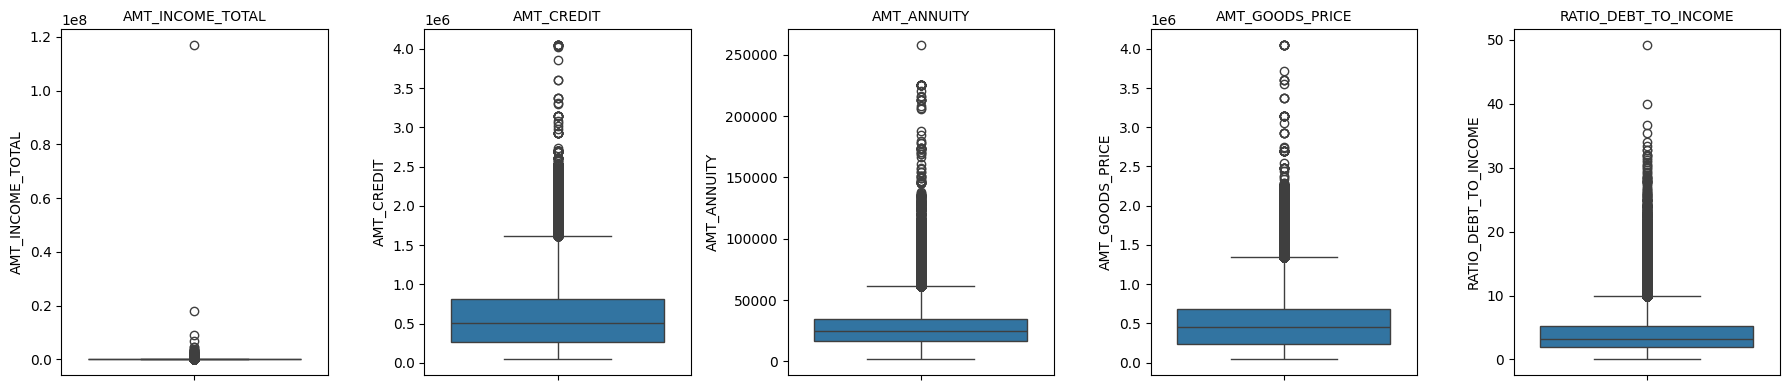

In [ ]:
# Boxplots for key numeric columns most likely to have extreme outliers — X_train only
key_numeric_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                     'RATIO_DEBT_TO_INCOME']

fig, axes = plt.subplots(1, len(key_numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, key_numeric_cols):
    sns.boxplot(y=X_train[col], ax=ax)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Investigate the extreme income outlier — using X_train's distribution
income_threshold = 10_000_000  # anything above 10M is almost certainly a data error at this income level
outlier_rows = X_train[X_train['AMT_INCOME_TOTAL'] > income_threshold]

print(f"X_train rows with income > {income_threshold:,}: {len(outlier_rows)}")
print(outlier_rows[['AMT_INCOME_TOTAL']])

print(f"\n99.9th percentile income (X_train): {X_train['AMT_INCOME_TOTAL'].quantile(0.999):,.2f}")
print(f"99th percentile income (X_train): {X_train['AMT_INCOME_TOTAL'].quantile(0.99):,.2f}")
print(f"Median income (X_train): {X_train['AMT_INCOME_TOTAL'].median():,.2f}")

X_train rows with income > 10,000,000: 2
        AMT_INCOME_TOTAL
12840        117000000.0
203693        18000090.0

99.9th percentile income (X_train): 900,000.00
99th percentile income (X_train): 472,500.00
Median income (X_train): 147,600.00


In [ ]:
# Removing the extreme income outliers (data entry errors, not real values).
# Fixed threshold, applied independently to each split — rows and their matching
# labels are dropped together so X/y stay aligned.
train_keep = X_train['AMT_INCOME_TOTAL'] <= income_threshold
test_keep = X_test['AMT_INCOME_TOTAL'] <= income_threshold

X_train, y_train = X_train[train_keep].reset_index(drop=True), y_train[train_keep].reset_index(drop=True)
X_test, y_test = X_test[test_keep].reset_index(drop=True), y_test[test_keep].reset_index(drop=True)

print(f"X_train rows removed: {(~train_keep).sum()} | new count: {len(X_train):,}")
print(f"X_test rows removed: {(~test_keep).sum()} | new count: {len(X_test):,}")

X_train rows removed: 2 | new count: 246,004
X_test rows removed: 1 | new count: 61,500


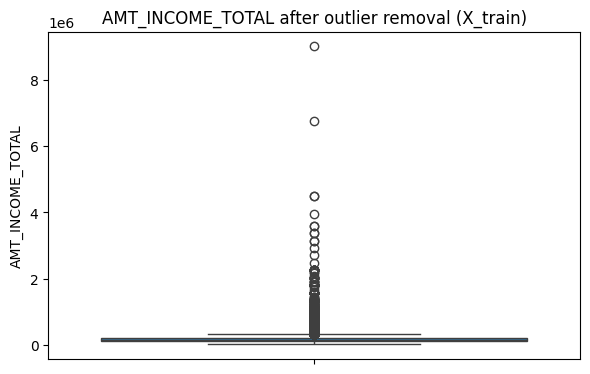

In [ ]:
# Confirm the income outlier removal visually — before vs after, on X_train
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
sns.boxplot(y=X_train['AMT_INCOME_TOTAL'], ax=axes)
axes.set_title('AMT_INCOME_TOTAL after outlier removal (X_train)')
plt.tight_layout()
plt.show()

## 6. Exploring Feature Relationships to Default

With a fully numeric, clean `X_train`, the next step is to look at which features show the
strongest relationship with the TARGET (default) outcome — first visually with a correlation
heatmap, then statistically with a Chi-Square test. **Both are computed exclusively on `X_train`/`y_train`.** This matters more here than anywhere else in the notebook: the Chi-Square results become one of five voting methods in Section 10's feature selection, so if they were computed using `y_test`, the test set's actual outcomes would have helped choose which features the model is allowed to learn from — before it was ever evaluated. No features are removed at this stage; this is purely diagnostic, feeding into the model training and later the feature-selection voting step.

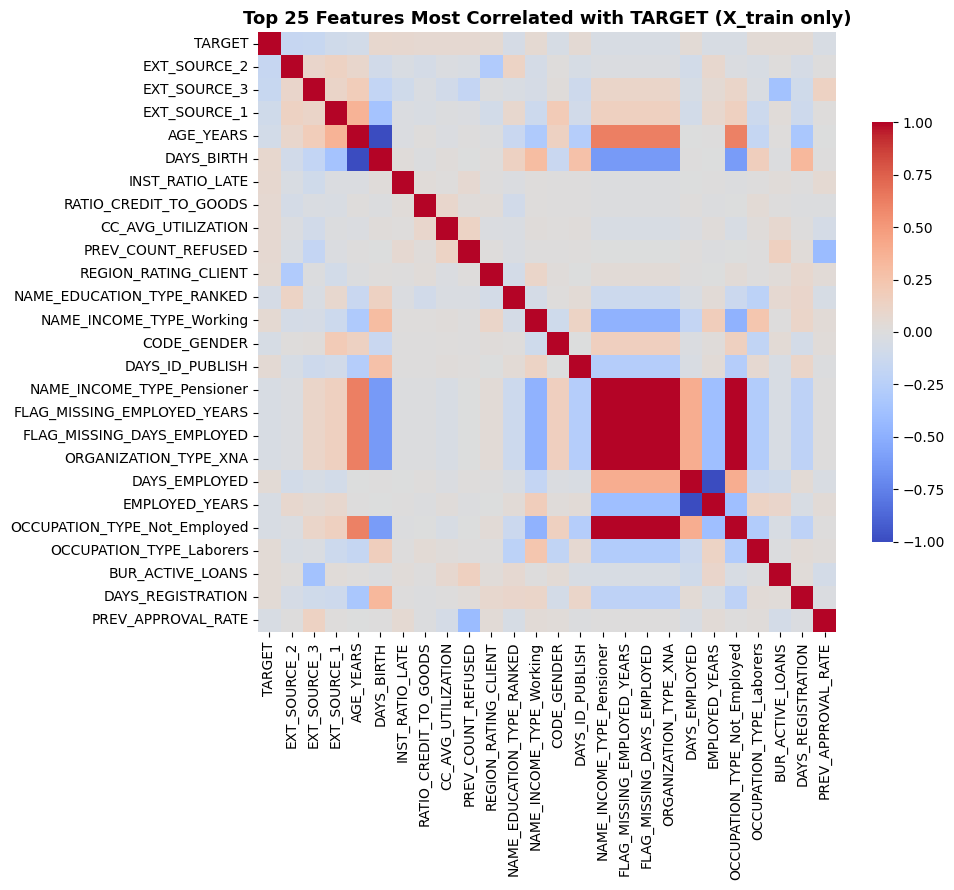

In [ ]:
# Correlation heatmap — showing only the top ~25 features most correlated with TARGET,
# computed on X_train/y_train only
train_with_target = X_train.copy()
train_with_target['TARGET'] = y_train.values

corr_with_target = train_with_target.corr(numeric_only=True)['TARGET'].abs().sort_values(ascending=False)
top_corr_features = corr_with_target.head(26).index.tolist()  # includes TARGET itself

plt.figure(figsize=(10, 9))
sns.heatmap(train_with_target[top_corr_features].corr(numeric_only=True), cmap='coolwarm', center=0,
            annot=False, cbar_kws={'shrink': 0.7})
plt.title('Top 25 Features Most Correlated with TARGET (X_train only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Pearson correlation only captures straight-line relationships, so any feature with a non-linear or threshold effect could be under-ranked here — that's part of why the final feature selection isn't based on correlation alone, but on five different methods that each catch different kinds of patterns.

Chi-Square requires purely numeric input. `NAME_EDUCATION_TYPE` is still sitting in `X_train` as raw text — its information is fully captured by `NAME_EDUCATION_TYPE_RANKED` already, so it's dropped from both splits below.

In [ ]:
# Find any remaining non-numeric columns in X_train
remaining_object_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print("Remaining text columns:", remaining_object_cols)

Remaining text columns: ['NAME_EDUCATION_TYPE']


In [ ]:
# Drop from BOTH splits, so the column set stays identical
X_train = X_train.drop(columns=['NAME_EDUCATION_TYPE'])
X_test = X_test.drop(columns=['NAME_EDUCATION_TYPE'])
print("Remaining text columns — X_train:", X_train.select_dtypes(include=['object']).columns.tolist())

Remaining text columns — X_train: []


One more type issue needs resolving first: `pd.get_dummies()` creates `True`/`False` boolean columns rather than 0/1 integers in newer pandas versions, and Chi-Square's non-negative shift step can't subtract on booleans. Every boolean column is converted to an integer below, in both splits, before Chi-Square runs.

In [ ]:
# Check for boolean columns (created by get_dummies) — these need to become 0/1 integers
for split_name, split_df in [('X_train', X_train), ('X_test', X_test)]:
    bool_cols = split_df.select_dtypes(include=['bool']).columns.tolist()
    split_df[bool_cols] = split_df[bool_cols].astype(int)
    print(f"{split_name} — boolean columns converted: {len(bool_cols)}, "
          f"remaining non-numeric columns: {split_df.select_dtypes(exclude=[np.number]).columns.tolist()}")

X_train — boolean columns converted: 97, remaining non-numeric columns: []
X_test — boolean columns converted: 96, remaining non-numeric columns: []


In [ ]:
# Chi-square, second (successful) attempt — X_train/y_train only
X_chi = X_train.apply(lambda col: col - col.min())
chi_scores, chi_pvalues = chi2(X_chi, y_train)

chi_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi2_Score': chi_scores,
    'p_value': chi_pvalues
}).sort_values('Chi2_Score', ascending=False)

print("Top 20 features by Chi-Square score (fit on X_train only):")
print(chi_results.head(20).to_string(index=False))

Top 20 features by Chi-Square score (fit on X_train only):
              Feature   Chi2_Score  p_value
      AMT_GOODS_PRICE 1.071629e+08      0.0
           AMT_CREDIT 6.829590e+07      0.0
     AMT_INCOME_TOTAL 9.021701e+06      0.0
  PREV_AVG_CREDIT_AMT 6.864816e+06      0.0
  BUR_MAX_OVERDUE_AMT 6.125416e+06      0.0
           DAYS_BIRTH 3.213927e+06      0.0
     PREV_AVG_ANNUITY 1.543843e+06      0.0
          AMT_ANNUITY 3.297132e+05      0.0
      DAYS_ID_PUBLISH 3.274131e+05      0.0
    DAYS_REGISTRATION 2.756701e+05      0.0
        DAYS_EMPLOYED 1.748754e+05      0.0
       BUR_TOTAL_DEBT 1.350390e+05      0.0
 CC_AVG_PAYMENT_RATIO 3.822098e+04      0.0
 BURBAL_MONTHS_CLOSED 2.098603e+04      0.0
  BURBAL_TOTAL_MONTHS 1.957369e+04      0.0
INST_AVG_UNDERPAYMENT 1.688313e+04      0.0
          POS_MAX_DPD 9.996063e+03      0.0
            AGE_YEARS 9.484568e+03      0.0
          POS_AVG_DPD 5.725143e+03      0.0
 BUR_AVG_DAYS_OVERDUE 5.210904e+03      0.0


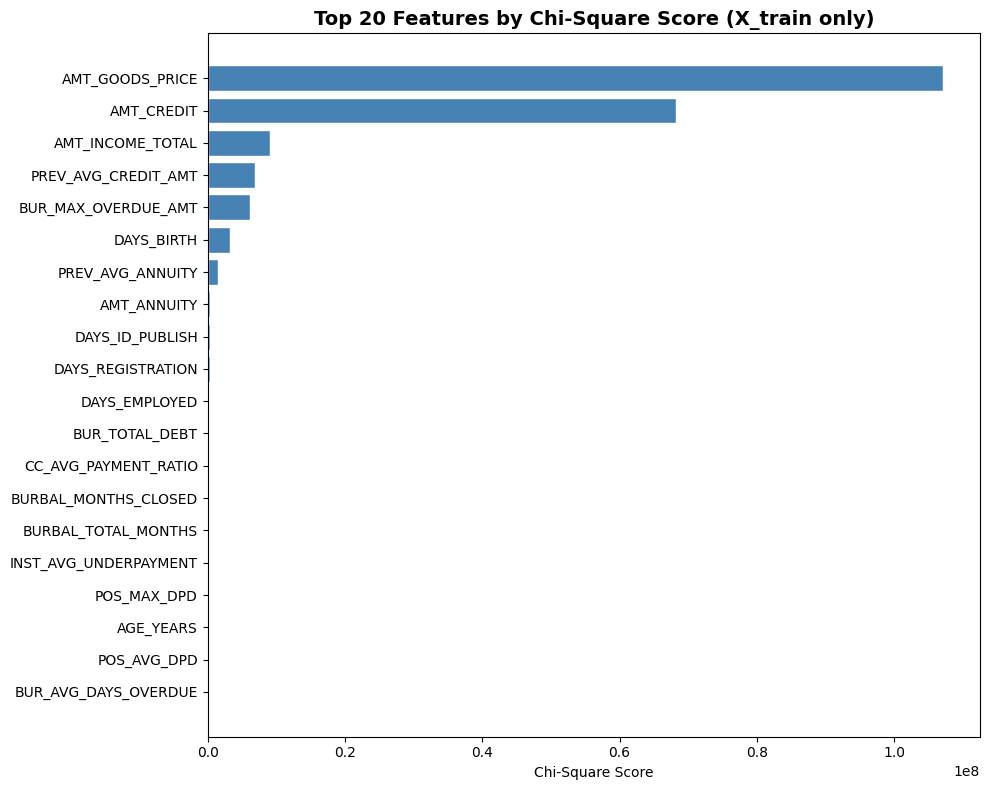

In [ ]:
# Chi-Square results as a horizontal bar chart
top_chi = chi_results.head(20).sort_values('Chi2_Score', ascending=True)  # ascending for horizontal bar order

plt.figure(figsize=(10, 8))
plt.barh(top_chi['Feature'], top_chi['Chi2_Score'], color='steelblue', edgecolor='white')
plt.xlabel('Chi-Square Score')
plt.title('Top 20 Features by Chi-Square Score (X_train only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Chi-square ranks large-magnitude dollar columns highest, which is a known scale sensitivity of the test on continuous data — this is one of the reasons I'm using five different methods rather than relying on any single one.

## 7. Baseline Model Training (Full Feature Set)

The train/test split already happened in Section 2.1, before any preprocessing — so unlike the previous version of this notebook, there's no split to do here. `SK_ID_CURR` was already dropped immediately after the split in Section 2.1, since it's an identifier, not a feature, and had no reason to be carried through Sections 3-6.

Three models are trained on the complete feature set to establish a baseline: Naive Bayes, Decision Tree, and Random Forest. All three use the same `X_train`/`y_train` and the same random seed, so any performance differences reflect the models themselves, not differences in the data they saw. `class_weight='balanced'` is used where supported to account for the roughly 92:8 class imbalance between repaid and defaulted applicants.

In [ ]:
print(f"X_train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"X_test: {X_test.shape[0]:,} rows, {X_test.shape[1]} features")

X_train: 246,004 rows, 194 features
X_test: 61,500 rows, 194 features


## 7.1 Testing for Multicollinearity (Justifying the Exclusion of Logistic Regression)

Logistic Regression was considered as a sixth feature-ranking/modeling method, since it is a
standard baseline in credit-scoring literature. However, Logistic Regression assumes low
multicollinearity between features — a real concern here, since several features are
engineered directly from the same underlying columns (e.g. the debt, annuity, and goods-price
ratios all derive from AMT_INCOME_TOTAL, AMT_CREDIT, and AMT_GOODS_PRICE). Variance Inflation
Factor (VIF) is used to test this directly before deciding whether to include Logistic
Regression, computed on `X_train` only. A VIF above 10 is generally considered evidence of serious multicollinearity.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requires a clean numeric matrix with no missing values — X_train already qualifies
# Checking a representative sample of financial/engineered columns most likely to be correlated
vif_check_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'RATIO_DEBT_TO_INCOME', 'RATIO_ANNUITY_TO_INCOME', 'RATIO_CREDIT_TO_GOODS',
    'AGE_YEARS', 'DAYS_BIRTH', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

X_vif = X_train[vif_check_cols].copy()

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== VARIANCE INFLATION FACTOR (VIF) CHECK ===")
print(vif_data.to_string(index=False))
print("\nVIF > 10 indicates serious multicollinearity.")

=== VARIANCE INFLATION FACTOR (VIF) CHECK ===
                Feature        VIF
             DAYS_BIRTH        inf
              AGE_YEARS        inf
          DAYS_EMPLOYED        inf
         EMPLOYED_YEARS        inf
             AMT_CREDIT 196.170974
        AMT_GOODS_PRICE 163.281905
RATIO_ANNUITY_TO_INCOME  46.832695
            AMT_ANNUITY  41.836810
   RATIO_DEBT_TO_INCOME  39.021740
  RATIO_CREDIT_TO_GOODS  34.066736
           EXT_SOURCE_1  16.343418
           EXT_SOURCE_3  10.090959
       AMT_INCOME_TOTAL   9.584200
           EXT_SOURCE_2   8.646863

VIF > 10 indicates serious multicollinearity.


### Conclusion: Logistic Regression Excluded

The VIF results confirm severe multicollinearity across the feature set. DAYS_BIRTH/AGE_YEARS
and DAYS_EMPLOYED/EMPLOYED_YEARS returned infinite VIF, since each pair is a direct linear
transformation of the other and carries no independent information. AMT_CREDIT and
AMT_GOODS_PRICE are also severely inflated, consistent with the engineered ratio
features (RATIO_CREDIT_TO_GOODS, RATIO_DEBT_TO_INCOME, RATIO_ANNUITY_TO_INCOME) being derived
directly from them.

Based on this evidence, **Logistic Regression is excluded** from both the feature-selection
voting and the model comparison. Its coefficient estimates would be unstable and difficult to
interpret under this level of multicollinearity, undermining the exact interpretability benefit
that would have justified including it. The feature-selection voting instead relies on five
methods (Pearson Correlation, Chi-Square, Naive Bayes, Decision Tree, Random Forest) that do
not share this assumption.

## 7.2 Why Recall and F2 Are the Deciding Metrics

Before training and comparing any models, it's worth being explicit about which metric actually decides "best," since this dataset makes accuracy a misleading default: with an ~92:8 class imbalance, a model that predicts "repaid" for every single applicant would score roughly 92% accuracy while catching zero defaulters — that's not a useful lending model, it's a model that looks good on the least informative metric available.

For a credit-risk classifier specifically, the two error types have very different real-world costs:

- **A false negative** (predicting an applicant will repay, when they actually default) costs the   bank the full unrecovered principal on that loan.
- **A false positive** (predicting an applicant will default, when they actually would have repaid)   costs the bank a missed opportunity — turning away a customer who would have been profitable.

Missing a real defaulter is the more expensive mistake, which is why **Recall** (the share of actual defaulters the model successfully catches) is prioritized, and **F2-Score** (which weights Recall twice as heavily as Precision) is used as the single summary metric when ranking models — instead of F1, which would treat both error types as equally costly, or plain Accuracy, which would reward the model above for doing nothing useful at all.

This doesn't mean Precision, false-positive rate, and specificity are ignored — they're reported alongside Recall and F2 for every model and every feature-set comparison in this notebook, specifically so the tradeoff is visible rather than hidden behind a single number. A model that pushes Recall up by flagging every applicant as high-risk would show that cost immediately in a collapsing Precision and specificity, and the tables below make that tradeoff explicit rather than letting F2 alone decide silently.

### 7.3 Training the three baseline models

Each model below is fit on `X_train`/`y_train`, with no feature selection applied yet — this is the full feature-set baseline. `class_weight='balanced'` is set on the Decision Tree and Random Forest (Naive Bayes has no such parameter) to counter the class imbalance. Predictions and predicted probabilities are saved for each model so they can be compared and reused later for feature-importance ranking and risk-tier binning. Training time is also captured for each model, to support the efficiency comparison in Section 11.

In [ ]:
nb_model = GaussianNB()
start = time.time()
nb_model.fit(X_train, y_train)
nb_train_time = time.time() - start
nb_preds = nb_model.predict(X_test)
nb_proba = nb_model.predict_proba(X_test)[:, 1]
print(f"Naive Bayes trained in {nb_train_time:.2f}s")

Naive Bayes trained in 1.20s


In [ ]:
dt_model = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)
start = time.time()
dt_model.fit(X_train, y_train)
dt_train_time = time.time() - start
dt_preds = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]
print(f"Decision Tree trained in {dt_train_time:.2f}s")

Decision Tree trained in 13.59s


In [ ]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print(f"Random Forest trained in {rf_train_time:.2f}s")

Random Forest trained in 177.02s


## 8. Baseline Model Evaluation (Full Feature Set)

With all three models trained on the identical train/test split and the complete feature set, their raw performance is compared using confusion matrices and a full metrics table. As explained in Section 7.2, Recall and F2-Score are the deciding metrics, but Precision, specificity, false positive rate, and true negatives are reported alongside them to keep the tradeoff visible.

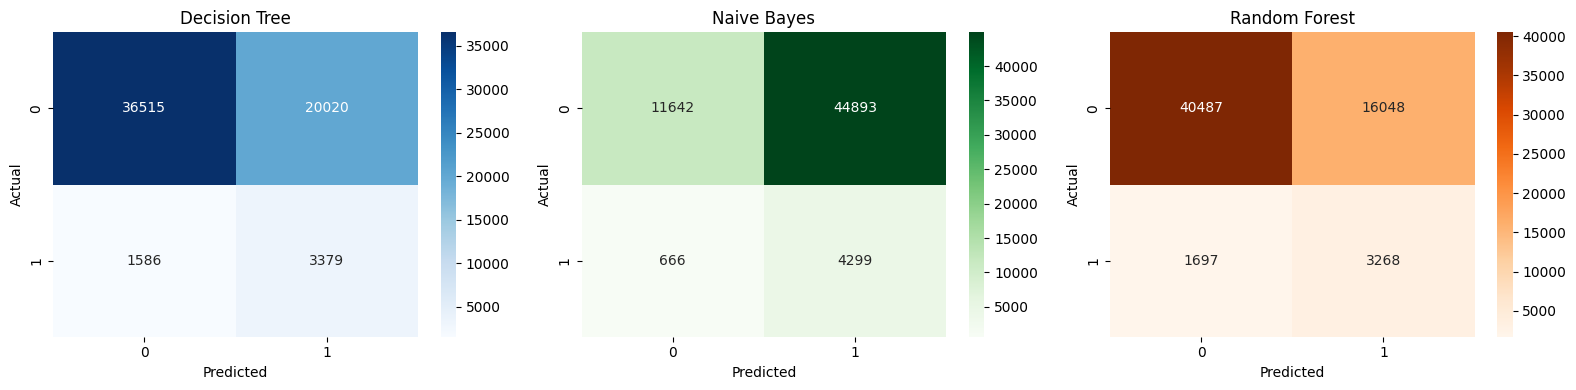

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Decision Tree'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Naive Bayes'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Oranges', ax=ax3)
ax3.set_title('Random Forest'); ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')

plt.tight_layout()
plt.show()

--- BASELINE MODEL COMPARISON (Full Feature Set, single split) ---
               Accuracy  Precision  Recall  Specificity     FPR  \
Decision Tree    0.6487     0.1444  0.6806       0.6459  0.3541   
Naive Bayes      0.2592     0.0874  0.8659       0.2059  0.7941   
Random Forest    0.7115     0.1692  0.6582       0.7161  0.2839   

               True Negatives  F1-Score  F2-Score  AUC-ROC  
Decision Tree         36515.0    0.2383    0.3906   0.7176  
Naive Bayes           11642.0    0.1588    0.3113   0.5974  
Random Forest         40487.0    0.2692    0.4171   0.7516  


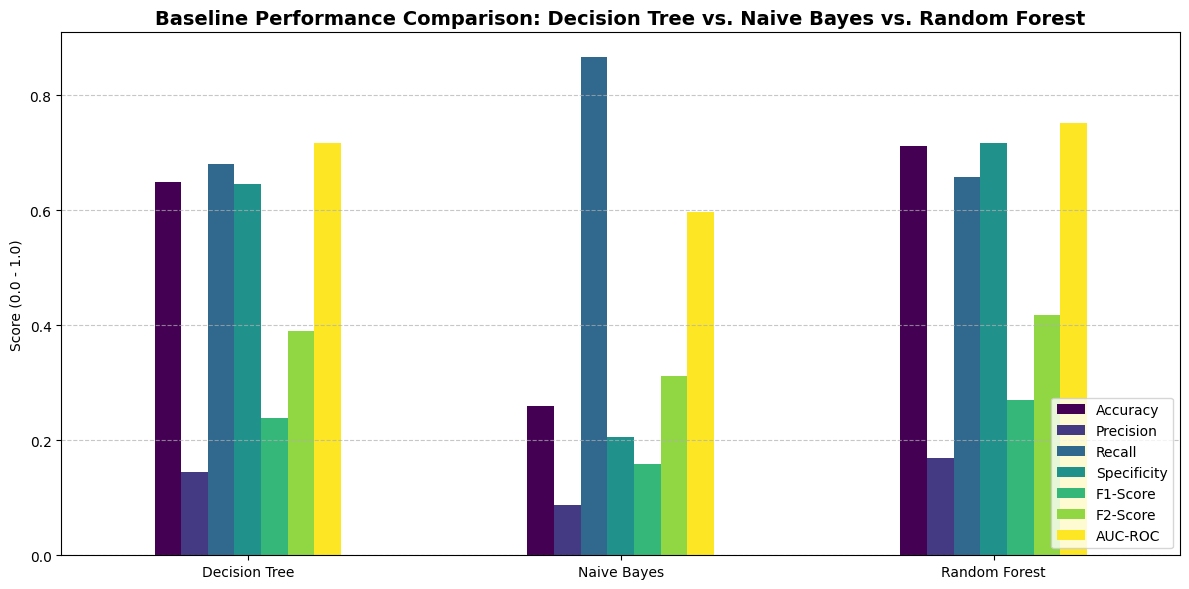

In [ ]:
def get_metrics_dict(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp),
        'FPR': fp / (fp + tn),
        'True Negatives': tn,
        'F1-Score': f1_score(y_true, y_pred),
        'F2-Score': fbeta_score(y_true, y_pred, beta=2),
        'AUC-ROC': roc_auc_score(y_true, y_proba)
    }

comparison_data = {
    'Decision Tree': get_metrics_dict(y_test, dt_preds, dt_proba),
    'Naive Bayes':   get_metrics_dict(y_test, nb_preds, nb_proba),
    'Random Forest': get_metrics_dict(y_test, rf_preds, rf_proba)
}

df_compare = pd.DataFrame(comparison_data).T

print("--- BASELINE MODEL COMPARISON (Full Feature Set, single split) ---")
print(df_compare.round(4))

df_compare[['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'F2-Score', 'AUC-ROC']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Baseline Performance Comparison: Decision Tree vs. Naive Bayes vs. Random Forest',
          fontsize=14, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 8.1 Cross-Validated Stability Check (Baseline Models)

A single 80/20 split can make a model look better or worse than it really is, just from which rows happened to land in the test set. Stratified 5-fold cross-validation re-fits each model 5 times on different train/validation splits of `X_train`, so the reported mean and standard deviation show whether the ranking above (Random Forest > Decision Tree > Naive Bayes) is a stable pattern or an artifact of one lucky split.

In [ ]:
def evaluate_with_kfold(model_class, model_params, X, y, n_splits=5, model_name='Model'):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_metrics = []
    print(f"=== {model_name} ===")
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

        model = model_class(**model_params)
        start = time.time()
        model.fit(X_fold_train, y_fold_train)
        train_time = time.time() - start

        preds = model.predict(X_fold_val)
        proba = model.predict_proba(X_fold_val)[:, 1]
        m = get_metrics_dict(y_fold_val, preds, proba)
        m['train_time_s'] = train_time
        fold_metrics.append(m)
        print(f"  Fold {fold}: AUC-ROC={m['AUC-ROC']:.4f}, Recall={m['Recall']:.4f}, "
              f"F2={m['F2-Score']:.4f}, train_time={train_time:.2f}s")

    fold_df = pd.DataFrame(fold_metrics)
    summary_mean = fold_df.mean()
    summary_std = fold_df.std()
    print(f"\n{model_name} — {n_splits}-Fold Summary:")
    for col in ['AUC-ROC', 'Recall', 'F2-Score', 'Precision', 'Specificity']:
        print(f"  {col}: {summary_mean[col]:.4f} +/- {summary_std[col]:.4f}")
    return fold_df, summary_mean, summary_std

In [ ]:
dt_fold_scores, dt_summary, dt_summary_std = evaluate_with_kfold(
    DecisionTreeClassifier, {'max_depth': 8, 'class_weight': 'balanced', 'random_state': RANDOM_STATE},
    X_train, y_train, model_name='Decision Tree')

nb_fold_scores, nb_summary, nb_summary_std = evaluate_with_kfold(
    GaussianNB, {}, X_train, y_train, model_name='Naive Bayes')

rf_fold_scores, rf_summary, rf_summary_std = evaluate_with_kfold(
    RandomForestClassifier,
    {'n_estimators': 300, 'max_depth': 8, 'class_weight': 'balanced', 'random_state': RANDOM_STATE, 'n_jobs': -1},
    X_train, y_train, model_name='Random Forest')

=== Decision Tree ===
  Fold 1: AUC-ROC=0.7082, Recall=0.6458, F2=0.3864, train_time=11.49s
  Fold 2: AUC-ROC=0.7180, Recall=0.6536, F2=0.3887, train_time=11.39s
  Fold 3: AUC-ROC=0.7103, Recall=0.6742, F2=0.3874, train_time=11.29s
  Fold 4: AUC-ROC=0.7032, Recall=0.6382, F2=0.3828, train_time=10.53s
  Fold 5: AUC-ROC=0.7142, Recall=0.6525, F2=0.3896, train_time=11.23s

Decision Tree — 5-Fold Summary:
  AUC-ROC: 0.7108 +/- 0.0057
  Recall: 0.6529 +/- 0.0134
  F2-Score: 0.3870 +/- 0.0026
  Precision: 0.1473 +/- 0.0023
  Specificity: 0.6679 +/- 0.0123
=== Naive Bayes ===
  Fold 1: AUC-ROC=0.6071, Recall=0.8877, F2=0.3146, train_time=1.21s
  Fold 2: AUC-ROC=0.6046, Recall=0.5735, F2=0.3091, train_time=1.20s
  Fold 3: AUC-ROC=0.6054, Recall=0.8633, F2=0.3135, train_time=1.08s
  Fold 4: AUC-ROC=0.6036, Recall=0.8593, F2=0.3125, train_time=0.83s
  Fold 5: AUC-ROC=0.5997, Recall=0.8920, F2=0.3116, train_time=0.77s

Naive Bayes — 5-Fold Summary:
  AUC-ROC: 0.6041 +/- 0.0028
  Recall: 0.8152 +/

In [ ]:
kfold_comparison = pd.DataFrame({
    'Decision Tree': dt_summary,
    'Naive Bayes': nb_summary,
    'Random Forest': rf_summary
}).T
kfold_std_comparison = pd.DataFrame({
    'Decision Tree': dt_summary_std,
    'Naive Bayes': nb_summary_std,
    'Random Forest': rf_summary_std
}).T

print("=== 5-FOLD CROSS-VALIDATION SUMMARY (mean) ===")
print(kfold_comparison.round(4))
print("\n=== 5-FOLD CROSS-VALIDATION SUMMARY (std) ===")
print(kfold_std_comparison.round(4))

=== 5-FOLD CROSS-VALIDATION SUMMARY (mean) ===
               Accuracy  Precision  Recall  Specificity     FPR  \
Decision Tree    0.6667     0.1473  0.6529       0.6679  0.3321   
Naive Bayes      0.3209     0.0919  0.8152       0.2775  0.7225   
Random Forest    0.7115     0.1683  0.6533       0.7166  0.2834   

               True Negatives  F1-Score  F2-Score  AUC-ROC  train_time_s  
Decision Tree         30207.2    0.2403    0.3870   0.7108       11.1862  
Naive Bayes           12549.4    0.1641    0.3123   0.6041        1.0191  
Random Forest         32410.2    0.2677    0.4145   0.7492      134.0810  

=== 5-FOLD CROSS-VALIDATION SUMMARY (std) ===
               Accuracy  Precision  Recall  Specificity     FPR  \
Decision Tree    0.0103     0.0023  0.0134       0.0123  0.0123   
Naive Bayes      0.1491     0.0094  0.1358       0.1741  0.1741   
Random Forest    0.0021     0.0014  0.0054       0.0024  0.0024   

               True Negatives  F1-Score  F2-Score  AUC-ROC  train_ti

## 9. Risk Tier Breakdown (Baseline Random Forest)

Since RQ2 asks for a 4-tier risk assignment (Low / Medium / High / Decline) rather than a
simple yes/no prediction, the best-performing baseline model's predicted default probabilities
are binned into four tiers. Because the true outcome only exists as a binary label
(repaid/defaulted), this is not a 4x4 confusion matrix — it is a 4x2 table showing the actual
outcome distribution within each predicted risk tier, which is the standard way a real risk
model is evaluated for business use.

In [ ]:
# Same binning as before, but with range values shown directly in the labels for clarity
risk_bins = [0, 0.10, 0.25, 0.40, 1.0]
risk_labels = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-40%)', 'Decline (40%+)']

risk_tiers = pd.cut(rf_proba, bins=risk_bins, labels=risk_labels, include_lowest=True)

tier_breakdown = pd.crosstab(risk_tiers, y_test.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
tier_breakdown.columns = ['Repaid (0)', 'Defaulted (1)']

# Fill in 0 for any tier with no applicants, instead of leaving it as NaN
tier_breakdown = tier_breakdown.reindex(risk_labels, fill_value=0)

tier_breakdown['Total Applicants'] = tier_breakdown.sum(axis=1)
tier_breakdown['Actual Default Rate'] = (tier_breakdown['Defaulted (1)'] / tier_breakdown['Total Applicants']).round(4)

print("=== BASELINE RANDOM FOREST — RISK TIER BREAKDOWN ===")
print(tier_breakdown)

=== BASELINE RANDOM FOREST — RISK TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   
Medium Risk (10-25%)        1347             14              1361   
High Risk (25-40%)         21091            546             21637   
Decline (40%+)             34097           4405             38502   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                      NaN  
Medium Risk (10-25%)               0.0103  
High Risk (25-40%)                 0.0252  
Decline (40%+)                     0.1144  


**Finding:** the Low Risk (0-10%) tier comes back completely empty - no applicant in the test set received a Random Forest probability below 10%. This isn't a bug in my binning; it's a real side effect of `class_weight='balanced'`, which I used to make the model treat the minority (default) class as more important during training given the ~92:8 imbalance. That correction systematically pushes predicted probabilities upward across the board, so a raw score from this model doesn't yet equal a true real-world default probability.

**This is worth stating plainly rather than as an aside: the tier boundaries and labels shown above are not yet usable to support a real lending decision.** The tier *ranking* is meaningful — the actual default rate climbs steadily from Medium to High to Decline — but the raw probability that determines which tier an applicant lands in is not yet a calibrated, real-world default probability. An applicant assigned "25% risk" here should not be read as "this applicant has roughly a 1-in-4 chance of defaulting" until the scores are corrected. Probability calibration (e.g. `CalibratedClassifierCV`) is required before these tier cutoffs — or any interest rate or approval policy built on top of them — can be treated as reflecting real-world default risk. That calibration step is planned for Milestone 4, not something this baseline model does yet.

## 10. Consensus Feature Selection (5-Method Voting)

To move from the full feature baseline to a leaner, more interpretable model, five
independent feature-ranking methods are combined: Pearson Correlation, Chi-Square, Naive
Bayes permutation importance, Decision Tree importance, and Random Forest importance. Features
are kept only if a majority of methods agree they matter, which also naturally limits the
influence of any single method's weaknesses (for example, Naive Bayes' rankings, given its
near-random overall performance) on the final feature set.

**Every one of the five methods below is fit on `X_train`/`y_train` only:**
- Correlation uses `X_train.corrwith(y_train)`.
- Chi-Square reuses `chi_results` from Section 6, which was itself computed on `X_train`/`y_train`   only (not the full dataset, and not test-set labels).
- Decision Tree and Random Forest importances come from `dt_model`/`rf_model`, both fit on   `X_train`/`y_train` in Section 7.
- Naive Bayes permutation importance is computed against `X_train`/`y_train` — **not** the test   set. Using `X_test`/`y_test` here would mean the held-out set directly decided which features the   final model is allowed to train on, which defeats the purpose of holding it out at all.

`X_test`/`y_test` play no role anywhere in this section. The resulting consensus features are then used to retrain Random Forest — the strongest baseline model — to produce an optimized model, evaluated on the test set exactly once, in Section 11.

In [ ]:
# Each method nominates its top 65 features toward the consensus vote
TOP_N = 65

# 1. Pearson Correlation with TARGET (X_train only)
corr_scores = X_train.corrwith(y_train).abs().sort_values(ascending=False)
list_corr = corr_scores.head(TOP_N).index.tolist()

# 2. Chi-Square (already computed on X_train/y_train in Section 6 as chi_results)
list_chi = chi_results.head(TOP_N)['Feature'].tolist()

# 3. Decision Tree importance (from the baseline Decision Tree, fit on X_train)
dt_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
list_dt = dt_importances.sort_values(ascending=False).head(TOP_N).index.tolist()

# 4. Random Forest importance (from the baseline Random Forest, fit on X_train)
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
list_rf = rf_importances.sort_values(ascending=False).head(TOP_N).index.tolist()

# 5. Naive Bayes permutation importance — computed against X_train/y_train, NOT the test set
nb_perm = permutation_importance(nb_model, X_train, y_train, n_repeats=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
nb_importances = pd.Series(nb_perm.importances_mean, index=X_train.columns)
list_nb = nb_importances.sort_values(ascending=False).head(TOP_N).index.tolist()

print(f"Correlation top 10: {list_corr[:10]}")
print(f"\nChi-Square top 10: {list_chi[:10]}")
print(f"\nDecision Tree top 10: {list_dt[:10]}")
print(f"\nRandom Forest top 10: {list_rf[:10]}")
print(f"\nNaive Bayes top 10: {list_nb[:10]}")

Correlation top 10: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'DAYS_BIRTH', 'AGE_YEARS', 'INST_RATIO_LATE', 'RATIO_CREDIT_TO_GOODS', 'CC_AVG_UTILIZATION', 'PREV_COUNT_REFUSED', 'REGION_RATING_CLIENT']

Chi-Square top 10: ['AMT_GOODS_PRICE', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'PREV_AVG_CREDIT_AMT', 'BUR_MAX_OVERDUE_AMT', 'DAYS_BIRTH', 'PREV_AVG_ANNUITY', 'AMT_ANNUITY', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION']

Decision Tree top 10: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'RATIO_CREDIT_TO_GOODS', 'INST_RATIO_LATE', 'INST_AVG_UNDERPAYMENT', 'BUR_AVG_UTILIZATION', 'CC_AVG_UTILIZATION', 'CODE_GENDER', 'DAYS_BIRTH']

Random Forest top 10: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'BUR_AVG_UTILIZATION', 'RATIO_CREDIT_TO_GOODS', 'AGE_YEARS', 'INST_RATIO_LATE', 'DAYS_BIRTH', 'EMPLOYED_YEARS', 'NAME_EDUCATION_TYPE_RANKED']

Naive Bayes top 10: ['DAYS_EMPLOYED', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'BURBAL_MONTHS_CLOSED', 'AMT

In [ ]:
# Build the voting scoreboard: 1 vote per method a feature appears in
all_methods = {
    'Correlation': list_corr,
    'Chi-Square': list_chi,
    'Decision Tree': list_dt,
    'Random Forest': list_rf,
    'Naive Bayes': list_nb
}

votes = pd.DataFrame(index=X_train.columns)
for method, feat_list in all_methods.items():
    votes[method] = votes.index.isin(feat_list).astype(int)

votes['Total_Votes'] = votes.sum(axis=1)
votes = votes.sort_values('Total_Votes', ascending=False)

print("=== FEATURE VOTING SCOREBOARD (top 30) ===")
print(votes.head(30))

print("\n=== VOTE COUNT DISTRIBUTION ===")
print(votes['Total_Votes'].value_counts().sort_index(ascending=False))

=== FEATURE VOTING SCOREBOARD (top 30) ===
                            Correlation  Chi-Square  Decision Tree  \
CODE_GENDER                           1           1              1   
DAYS_BIRTH                            1           1              1   
AMT_CREDIT                            1           1              1   
AMT_GOODS_PRICE                       1           1              1   
DAYS_REGISTRATION                     1           1              1   
DAYS_EMPLOYED                         1           1              1   
DAYS_ID_PUBLISH                       1           1              1   
EXT_SOURCE_2                          1           1              1   
REGION_RATING_CLIENT                  1           1              1   
EXT_SOURCE_3                          1           1              1   
INST_RATIO_LATE                       1           1              1   
BUR_ACTIVE_LOANS                      1           1              1   
DEF_30_CNT_SOCIAL_CIRCLE              1        

In [ ]:
# Protect the top 10 from each individual method, regardless of vote count,
# then add any additional features that meet the 2+ vote consensus threshold
TOP_PROTECTED = 10

protected_features = set()
for method_list in [list_corr, list_chi, list_dt, list_rf, list_nb]:
    protected_features.update(method_list[:TOP_PROTECTED])

print(f"Protected features (top {TOP_PROTECTED} from each of 5 methods, deduplicated): {len(protected_features)}")

CONSENSUS_THRESHOLD = 2
consensus_features = set(votes[votes['Total_Votes'] >= CONSENSUS_THRESHOLD].index.tolist())

final_feature_selection = sorted(protected_features | consensus_features)

FULL_FEATURE_COUNT = X_train.shape[1]
print(f"Consensus features (>= {CONSENSUS_THRESHOLD} votes): {len(consensus_features)}")
print(f"Final combined feature set (protected + consensus): {len(final_feature_selection)}")
print(f"Percentage of original {FULL_FEATURE_COUNT} retained: {len(final_feature_selection)/FULL_FEATURE_COUNT:.1%}")
print(f"\nFinal feature list:")
print(final_feature_selection)

Protected features (top 10 from each of 5 methods, deduplicated): 28
Consensus features (>= 2 votes): 82
Final combined feature set (protected + consensus): 82
Percentage of original 194 retained: 42.3%

Final feature list:
['AGE_YEARS', 'AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'BURBAL_MONTHS_CLOSED', 'BURBAL_MONTHS_OVERDUE', 'BURBAL_TOTAL_MONTHS', 'BUR_ACTIVE_LOANS', 'BUR_AVG_DAYS_OVERDUE', 'BUR_AVG_UTILIZATION', 'BUR_MAX_OVERDUE_AMT', 'BUR_TOTAL_DEBT', 'BUR_TOTAL_LOANS', 'CC_AVG_PAYMENT_RATIO', 'CC_AVG_UTILIZATION', 'CNT_CHILDREN', 'CODE_GENDER', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EMPLOYED_YEARS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_MON', 'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_QRT', 'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_YEAR', 'FLAG_MISS

To avoid discarding a feature that one method considers highly important even without broader agreement, the top 10 features from each individual method were protected from elimination regardless of vote count, in addition to the standard 2+ vote consensus threshold.

### Consensus Feature Selection Result

Using a 2-of-5 method consensus threshold, with the top 10 features from each individual
method protected from elimination regardless of vote count, the feature set was reduced from
the full feature count down to the consensus set printed above — and this time, every one of the five votes was cast using training data only. The resulting feature set spans
external credit bureau scores, applicant demographics, bureau/credit-card/installment history
aggregates, and their associated missingness flags — consistent with the behavioral and
demographic indicators identified as most predictive in the correlation and chi-square analysis.

**Note on reproducing this exact figure:** because Chi-Square and Naive Bayes permutation importance are now computed on `X_train` instead of the full dataset (Chi-Square) or `X_test` (Naive Bayes), the exact vote counts and final feature count here may differ somewhat from the pre-fix version of this notebook — that's expected, and is exactly the kind of change this fix is meant to surface rather than hide.

### What Changed: Feature Groups Retained vs. Removed

To make the effect of feature selection legible at a glance rather than only as a raw count drop, the full feature set and the consensus set are grouped into broad categories below, based on column-name prefixes established during Milestone 1's relational aggregation.

In [ ]:
def categorize_feature(col):
    if col.startswith('FLAG_MISSING_'):
        return 'Missingness Flags'
    if col.startswith('EXT_SOURCE'):
        return 'External Credit Scores'
    if col.startswith('BUR_') or col.startswith('BURBAL_'):
        return 'Credit Bureau History'
    if col.startswith('CC_'):
        return 'Credit Card History'
    if col.startswith('PREV_'):
        return 'Previous Applications'
    if col.startswith('INST_'):
        return 'Installment History'
    if col.startswith('POS_'):
        return 'POS/Cash History'
    if col.startswith('OCCUPATION_TYPE') or col.startswith('ORGANIZATION_TYPE') \
       or col.startswith('NAME_INCOME_TYPE') or col.startswith('NAME_FAMILY_STATUS') \
       or col.startswith('NAME_HOUSING_TYPE') or col in ['CODE_GENDER', 'NAME_EDUCATION_TYPE_RANKED',
                                                            'CNT_FAM_MEMBERS', 'CNT_CHILDREN']:
        return 'Demographics'
    if col.startswith('RATIO_') or col.startswith('AMT_') or col in ['DAYS_BIRTH', 'AGE_YEARS',
                                                                        'DAYS_EMPLOYED', 'EMPLOYED_YEARS']:
        return 'Financial / Engineered Ratios'
    return 'Other'

feature_groups = pd.DataFrame({'Feature': X_train.columns})
feature_groups['Group'] = feature_groups['Feature'].apply(categorize_feature)
feature_groups['Retained'] = feature_groups['Feature'].isin(final_feature_selection)

group_summary = feature_groups.groupby('Group').agg(
    Full_Count=('Feature', 'count'),
    Retained_Count=('Retained', 'sum')
)
group_summary['Removed_Count'] = group_summary['Full_Count'] - group_summary['Retained_Count']
group_summary['Retention_Rate'] = (group_summary['Retained_Count'] / group_summary['Full_Count']).round(2)
group_summary = group_summary.sort_values('Full_Count', ascending=False)

print("=== FEATURE GROUPS: RETAINED vs. REMOVED ===")
print(group_summary)

=== FEATURE GROUPS: RETAINED vs. REMOVED ===
                               Full_Count  Retained_Count  Removed_Count  \
Group                                                                      
Demographics                          101              17             84   
Missingness Flags                      38              13             25   
Financial / Engineered Ratios          14              14              0   
Credit Bureau History                  10               9              1   
Other                                   8               8              0   
Previous Applications                   6               6              0   
Installment History                     6               6              0   
Credit Card History                     4               2              2   
POS/Cash History                        4               4              0   
External Credit Scores                  3               3              0   

                               Retention_R

## 11. Optimized Model: Random Forest on Consensus Features

Random Forest was the strongest-performing baseline model, so it is retrained here on the
consensus feature set produced by the feature-selection voting step, using identical hyperparameters,
random seed, and train/test split as the baseline model. This isolates the effect of feature
selection alone — any change in performance reflects the trimmed feature set, not a different
model configuration. `X_test` is used here for the first time since Section 2.1's split — this is the single, final evaluation this notebook performs on it.

In [ ]:
# Retrain Random Forest (best baseline model) on the consensus feature set
X_train_optimized = X_train[final_feature_selection]
X_test_optimized = X_test[final_feature_selection]

rf_model_optimized = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1)
start = time.time()
rf_model_optimized.fit(X_train_optimized, y_train)
rf_optimized_train_time = time.time() - start

rf_preds_optimized = rf_model_optimized.predict(X_test_optimized)
rf_proba_optimized = rf_model_optimized.predict_proba(X_test_optimized)[:, 1]

print(f"Optimized Random Forest trained on {len(final_feature_selection)} features in "
      f"{rf_optimized_train_time:.2f}s (baseline took {rf_train_time:.2f}s on "
      f"{X_train.shape[1]} features).")

Optimized Random Forest trained on 82 features in 213.15s (baseline took 177.02s on 194 features).


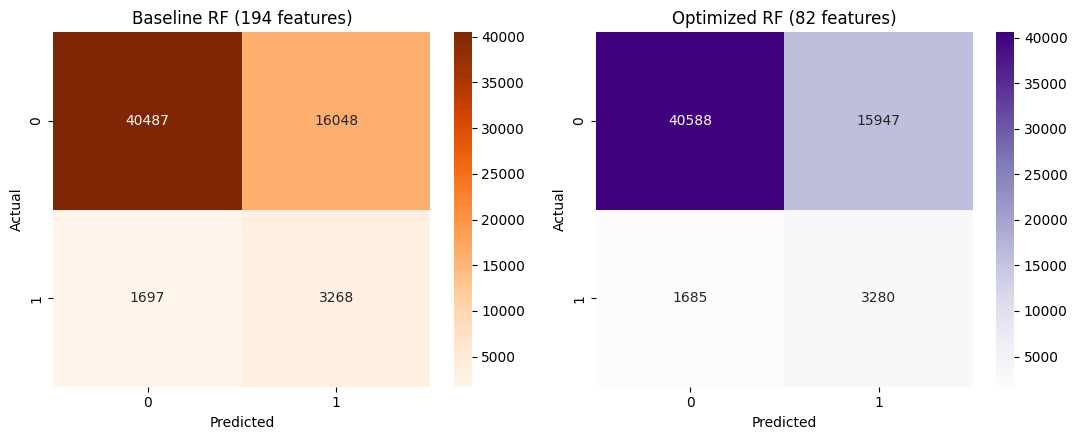

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Oranges', ax=ax1)
ax1.set_title(f'Baseline RF ({X_train.shape[1]} features)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds_optimized), annot=True, fmt='d', cmap='Purples', ax=ax2)
ax2.set_title(f'Optimized RF ({len(final_feature_selection)} features)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

=== RANDOM FOREST: BASELINE vs. OPTIMIZED (single split) ===
                            Accuracy  Precision  Recall  Specificity     FPR  \
Baseline RF (194 features)    0.7115     0.1692  0.6582       0.7161  0.2839   
Optimized RF (82 features)    0.7133     0.1706  0.6606       0.7179  0.2821   

                            True Negatives  F1-Score  F2-Score  AUC-ROC  
Baseline RF (194 features)         40487.0    0.2692    0.4171   0.7516  
Optimized RF (82 features)         40588.0    0.2712    0.4196   0.7533  


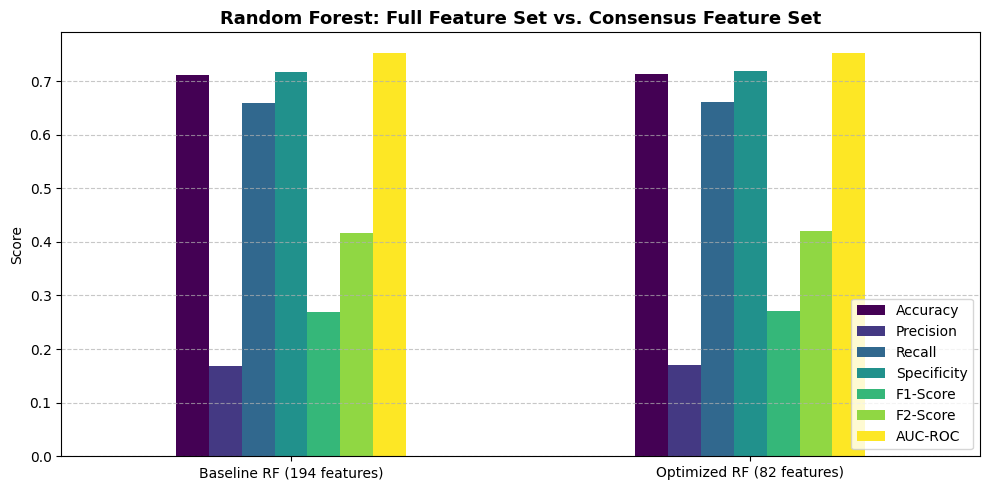

In [ ]:
comparison_data = {
    f'Baseline RF ({X_train.shape[1]} features)': get_metrics_dict(y_test, rf_preds, rf_proba),
    f'Optimized RF ({len(final_feature_selection)} features)': get_metrics_dict(y_test, rf_preds_optimized, rf_proba_optimized)
}

df_rf_compare = pd.DataFrame(comparison_data).T
print("=== RANDOM FOREST: BASELINE vs. OPTIMIZED (single split) ===")
print(df_rf_compare.round(4))

df_rf_compare[['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'F2-Score', 'AUC-ROC']].plot(
    kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Random Forest: Full Feature Set vs. Consensus Feature Set', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 11.1 Efficiency: Full vs. Selected Feature Set

Beyond predictive performance, the consensus feature set's practical value also comes from being smaller and faster to work with. Model complexity is approximated here by the average number of nodes across the forest's decision trees — fewer features generally means each tree needs fewer splits to separate the data, producing a simpler, more interpretable forest.

In [ ]:
baseline_avg_nodes = np.mean([t.tree_.node_count for t in rf_model.estimators_])
optimized_avg_nodes = np.mean([t.tree_.node_count for t in rf_model_optimized.estimators_])

efficiency_comparison = pd.DataFrame({
    'Baseline RF': {
        'Feature Count': X_train.shape[1],
        'Train Time (s)': round(rf_train_time, 2),
        'Avg. Nodes per Tree': round(baseline_avg_nodes, 1)
    },
    'Optimized RF': {
        'Feature Count': len(final_feature_selection),
        'Train Time (s)': round(rf_optimized_train_time, 2),
        'Avg. Nodes per Tree': round(optimized_avg_nodes, 1)
    }
}).T

efficiency_comparison['Feature Reduction'] = (
    f"{(1 - len(final_feature_selection) / X_train.shape[1]):.1%}"
)

print("=== EFFICIENCY: BASELINE vs. OPTIMIZED RANDOM FOREST ===")
print(efficiency_comparison)

=== EFFICIENCY: BASELINE vs. OPTIMIZED RANDOM FOREST ===
              Feature Count  Train Time (s)  Avg. Nodes per Tree  \
Baseline RF           194.0          177.02                451.5   
Optimized RF           82.0          213.15                468.0   

             Feature Reduction  
Baseline RF              57.7%  
Optimized RF             57.7%  


### 11.2 Cross-Validated Stability Check: Is the Feature Selection Stable?

The single-split comparison above shows a snapshot; 5-fold cross-validation on `X_train` shows whether the consensus feature set holds up across different slices of the training data, or whether it only looks competitive because of how this particular split happened to fall.

In [ ]:
rf_optimized_fold_scores, rf_optimized_summary, rf_optimized_summary_std = evaluate_with_kfold(
    RandomForestClassifier,
    {'n_estimators': 300, 'max_depth': 8, 'class_weight': 'balanced', 'random_state': RANDOM_STATE, 'n_jobs': -1},
    X_train[final_feature_selection], y_train, model_name=f'Optimized RF ({len(final_feature_selection)} features)')

=== Optimized RF (82 features) ===
  Fold 1: AUC-ROC=0.7526, Recall=0.6488, F2=0.4164, train_time=154.86s
  Fold 2: AUC-ROC=0.7513, Recall=0.6475, F2=0.4141, train_time=159.30s
  Fold 3: AUC-ROC=0.7526, Recall=0.6561, F2=0.4199, train_time=162.60s
  Fold 4: AUC-ROC=0.7483, Recall=0.6495, F2=0.4151, train_time=159.55s
  Fold 5: AUC-ROC=0.7528, Recall=0.6575, F2=0.4181, train_time=157.67s

Optimized RF (82 features) — 5-Fold Summary:
  AUC-ROC: 0.7515 +/- 0.0019
  Recall: 0.6519 +/- 0.0046
  F2-Score: 0.4167 +/- 0.0023
  Precision: 0.1706 +/- 0.0010
  Specificity: 0.7216 +/- 0.0021


In [ ]:
feature_selection_stability = pd.DataFrame({
    f'Baseline RF ({X_train.shape[1]} features)': rf_summary,
    f'Optimized RF ({len(final_feature_selection)} features)': rf_optimized_summary
}).T

feature_selection_stability_std = pd.DataFrame({
    f'Baseline RF ({X_train.shape[1]} features)': rf_summary_std,
    f'Optimized RF ({len(final_feature_selection)} features)': rf_optimized_summary_std
}).T

print("=== 5-FOLD MEAN: BASELINE vs. OPTIMIZED FEATURE SET ===")
print(feature_selection_stability.round(4))
print("\n=== 5-FOLD STD: BASELINE vs. OPTIMIZED FEATURE SET ===")
print(feature_selection_stability_std.round(4))

print("\nIf the optimized set's mean AUC-ROC/Recall/F2 sit within roughly one standard deviation "
      "of the baseline's, the 82-feature reduction is not costing meaningful predictive power, "
      "and its narrower std (if narrower) indicates the smaller feature set is at least as stable, "
      "not just as accurate on average, across different training folds.")

=== 5-FOLD MEAN: BASELINE vs. OPTIMIZED FEATURE SET ===
                            Accuracy  Precision  Recall  Specificity     FPR  \
Baseline RF (194 features)    0.7115     0.1683  0.6533       0.7166  0.2834   
Optimized RF (82 features)    0.7160     0.1706  0.6519       0.7216  0.2784   

                            True Negatives  F1-Score  F2-Score  AUC-ROC  \
Baseline RF (194 features)         32410.2    0.2677    0.4145   0.7492   
Optimized RF (82 features)         32639.2    0.2704    0.4167   0.7515   

                            train_time_s  
Baseline RF (194 features)      134.0810  
Optimized RF (82 features)      158.7955  

=== 5-FOLD STD: BASELINE vs. OPTIMIZED FEATURE SET ===
                            Accuracy  Precision  Recall  Specificity     FPR  \
Baseline RF (194 features)    0.0021     0.0014  0.0054       0.0024  0.0024   
Optimized RF (82 features)    0.0018     0.0010  0.0046       0.0021  0.0021   

                            True Negatives  F1-Scor

In [ ]:
risk_bins = [0, 0.10, 0.25, 0.40, 1.0]
risk_labels = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-40%)', 'Decline (40%+)']

def build_tier_table(proba, y_true):
    tiers = pd.cut(proba, bins=risk_bins, labels=risk_labels, include_lowest=True)
    table = pd.crosstab(tiers, y_true.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
    table.columns = ['Repaid (0)', 'Defaulted (1)']
    table = table.reindex(risk_labels, fill_value=0)
    table['Total Applicants'] = table.sum(axis=1)
    table['Actual Default Rate'] = (table['Defaulted (1)'] / table['Total Applicants']).round(4)
    return table

baseline_tiers = build_tier_table(rf_proba, y_test)
optimized_tiers = build_tier_table(rf_proba_optimized, y_test)

print(f"=== BASELINE RF ({X_train.shape[1]} features) — RISK TIER BREAKDOWN ===")
print(baseline_tiers)
print(f"\n=== OPTIMIZED RF ({len(final_feature_selection)} features) — RISK TIER BREAKDOWN ===")
print(optimized_tiers)

=== BASELINE RF (194 features) — RISK TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   
Medium Risk (10-25%)        1347             14              1361   
High Risk (25-40%)         21091            546             21637   
Decline (40%+)             34097           4405             38502   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                      NaN  
Medium Risk (10-25%)               0.0103  
High Risk (25-40%)                 0.0252  
Decline (40%+)                     0.1144  

=== OPTIMIZED RF (82 features) — RISK TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   

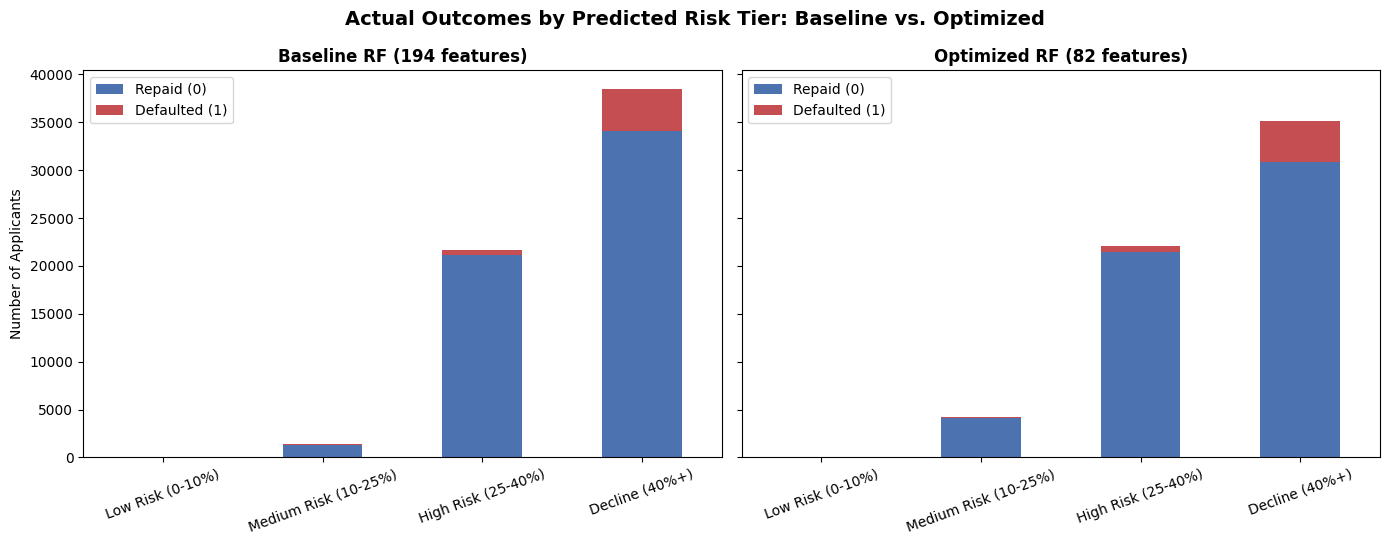

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

baseline_tiers[['Repaid (0)', 'Defaulted (1)']].plot(kind='bar', stacked=True, ax=ax1,
                                                        color=['#4C72B0', '#C44E52'])
ax1.set_title(f'Baseline RF ({X_train.shape[1]} features)', fontweight='bold')
ax1.set_ylabel('Number of Applicants')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=20)

optimized_tiers[['Repaid (0)', 'Defaulted (1)']].plot(kind='bar', stacked=True, ax=ax2,
                                                         color=['#4C72B0', '#C44E52'])
ax2.set_title(f'Optimized RF ({len(final_feature_selection)} features)', fontweight='bold')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=20)

fig.suptitle('Actual Outcomes by Predicted Risk Tier: Baseline vs. Optimized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Exporting Data for Milestone 4

**This changed from the previous version of this notebook.** Previously, `df` — a single, re-merged dataframe — was exported, and Milestone 4 performed its own fresh `train_test_split` on top of it. That meant Milestone 4 used a *different* random split than this notebook, on data that had already been preprocessed using full-dataset statistics — reintroducing the same leakage this rebuild fixes, one notebook downstream.

Instead, `X_train`, `X_test`, `y_train`, and `y_test` — already split first, already preprocessed using only training-derived statistics — are exported directly. Milestone 4 should load these files as-is rather than re-splitting anything.

In [ ]:
# Save the already-split, already-preprocessed data so Milestone 4 loads it directly
# instead of re-running cleaning/encoding or re-splitting
output_dir = '/content/drive/MyDrive/CIND820_Project'

X_train.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test.to_csv(f'{output_dir}/X_test.csv', index=False)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)

print(f"Saved X_train: {X_train.shape}")
print(f"Saved X_test: {X_test.shape}")
print(f"Saved y_train: {y_train.shape}")
print(f"Saved y_test: {y_test.shape}")

# Print the consensus feature list in copy-paste-ready Python format
print("\nfinal_feature_selection = [")
for feat in final_feature_selection:
    print(f"    '{feat}',")
print("]")

# Also save it to a text file on Drive as a backup
with open(f'{output_dir}/final_feature_selection.txt', 'w') as f:
    f.write(str(final_feature_selection))
print(f"\nSaved {len(final_feature_selection)} features to final_feature_selection.txt")

Saved X_train: (246004, 194)
Saved X_test: (61500, 194)
Saved y_train: (246004,)
Saved y_test: (61500,)

final_feature_selection = [
    'AGE_YEARS',
    'AMT_ANNUITY',
    'AMT_CREDIT',
    'AMT_GOODS_PRICE',
    'AMT_INCOME_TOTAL',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR',
    'BURBAL_MONTHS_CLOSED',
    'BURBAL_MONTHS_OVERDUE',
    'BURBAL_TOTAL_MONTHS',
    'BUR_ACTIVE_LOANS',
    'BUR_AVG_DAYS_OVERDUE',
    'BUR_AVG_UTILIZATION',
    'BUR_MAX_OVERDUE_AMT',
    'BUR_TOTAL_DEBT',
    'BUR_TOTAL_LOANS',
    'CC_AVG_PAYMENT_RATIO',
    'CC_AVG_UTILIZATION',
    'CNT_CHILDREN',
    'CODE_GENDER',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_ID_PUBLISH',
    'DAYS_REGISTRATION',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'EMPLOYED_YEARS',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_MON',
    'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_QRT',
    'FLAG_MIS